In [1]:
import scanpy as sc
import sys
sys.path.append('/Users/amossi/Documents/code/')
import FISHspace as sp

%reload_ext autoreload
%autoreload 2

/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/amossi/.local/share/mamba/envs/py310/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['pdf.fonttype'] = 42

# save figure with no pad
mpl.rcParams['savefig.pad_inches'] = 0
mpl.rcParams['savefig.bbox'] = 'tight'

# set axes width
mpl.rcParams['axes.linewidth'] = 0.2
mpl.rcParams['xtick.minor.pad'] = 0
mpl.rcParams['xtick.major.pad'] = 0
mpl.rcParams['ytick.minor.pad'] = 0
mpl.rcParams['ytick.major.pad'] = 0
mpl.rcParams['xtick.minor.width'] = 0.2
mpl.rcParams['xtick.major.width'] = 0.2
mpl.rcParams['ytick.minor.width'] = 0.2
mpl.rcParams['ytick.major.width'] = 0.2



In [ ]:
#adata = sc.read_h5ad('../../EEL_AnnData/EEL_41CleanNuclei-CellularNgh_FeaturesMN.h5ad')
import pandas as pd
eel_path = '../../data_for_visualization/GBM_Linnarsson_EEL_revision.h5ad'
adata = sc.read_h5ad(eel_path)
rename_dic = {
    'WR 5':'WR Endo.Ass.',
    'WR 2':'WR Periphery1',
    'WR 3':'WR Periphery2',
    'WR 1':'WR Periphery3',
    
    'WR 6':'WR HYP2',
    'WR 8':'WR HYP1',
    'WR 7':'WR OPC',
    'WR 4':'WR nIPC',
    
    'nIPC-RG-like':'RG-like',
    
 
}

adata.obs['m-states'] = pd.Categorical([rename_dic[m] if m in rename_dic else m for m in adata.obs['m-states']])
adata.obs['m-states'] = pd.Categorical(['Endothelial' if m.count('Endothelial') else m for m in adata.obs['m-states']])
adata.obs['m-states'] = pd.Categorical(['Mural' if x.count('Mural') else x for x in adata.obs['m-states']])


In [8]:

palette_common = {
  
    'WR Endo.Ass.':'#CFA8D1', 
    'WR Periphery1':'#EDE8F3',
    'WR Periphery2':'#E2D8EA',
    'WR Periphery3':'#D6BEDD', 
    'WR HYP1':'#C50F53', 
    'WR HYP2': '#840034', 
    'WR OPC':'#A40447', 
    'WR nIPC': '#e43c96',
    
    'Endothelial':'#C8E683', # '#d5b8ff',  
    'Mural': '#C8E683',
}   

In [9]:
palette_common.keys()

dict_keys(['WR Endo.Ass.', 'WR Periphery1', 'WR Periphery2', 'WR Periphery3', 'WR HYP1', 'WR HYP2', 'WR OPC', 'WR nIPC', 'Endothelial', 'Mural'])

INFO:root:First filter, 85582 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 10008 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


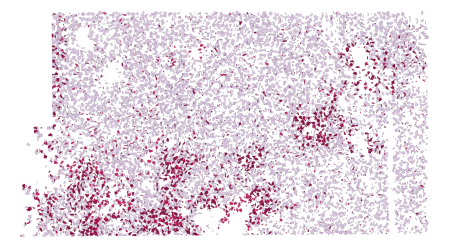

In [11]:
sp.pl.plot_polygons(
    adata,
    sample='SL002',
    cluster_key='m-states',
    clusters=['WR Periphery3','WR HYP2', 'WR HYP1'], #[45,76],
    alpha=0.9,
    show_axis=False,
    show_scalebar=False,
    palette= palette_common,
    figsize=(5,5),
    save=True,
    savepath='figures/SL002.svg',
    xlim=(0,5000),
    ylim=(0,6000),
)

#plt.savefig('figures/SL002.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

INFO:root:First filter, 156221 cells left
INFO:root:Zoom filter, 156221 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


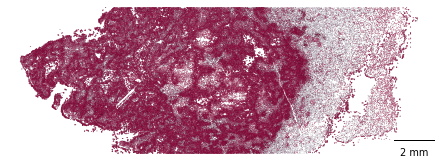

In [12]:
sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['WR Periphery3','WR HYP2', 'WR HYP1',], #[45,76],
    alpha=0.9,
    show_axis=False,
    show_scalebar=True,
    palette= palette_common,
    figsize=(5,5),
    save=True,
    savepath='figures/SL035B.svg',

)

#plt.savefig('figures/SL002.svg',dpi=300, format='svg', transparent=True,bbox_inches='tight')

In [14]:
import numpy as np
WR = adata[adata.obs['m-states'].isin(['WR Endo.Ass.', 'WR Periphery1', 'WR Periphery2', 'WR Periphery3', 'WR HYP1', 'WR HYP2', 'WR OPC', 'WR nIPC', 'Endothelial', 'Mural'])]

In [19]:
vmax=np.quantile(WR[:,gene].X.toarray(), .99)

INFO:root:First filter, 209525 cells left


CD44


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 4.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


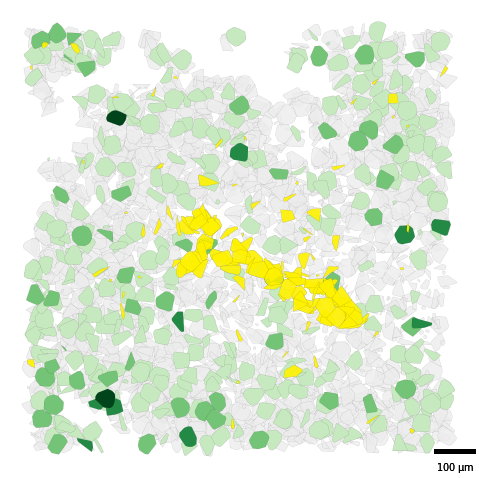

INFO:root:First filter, 209525 cells left


ANXA1


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 6.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


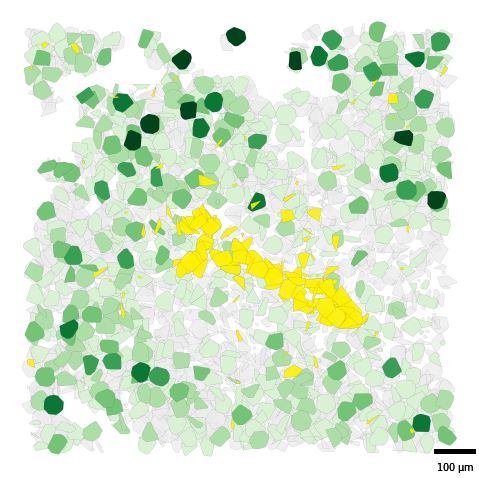

INFO:root:First filter, 209525 cells left


ANXA2


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 4.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


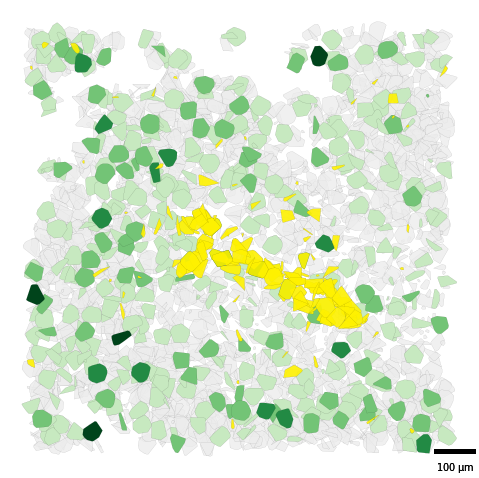

INFO:root:First filter, 209525 cells left


HIF1A


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 3.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


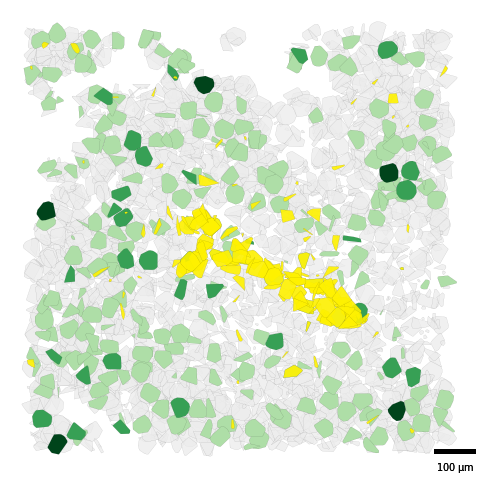

INFO:root:First filter, 209525 cells left


SLC2A1


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 3.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


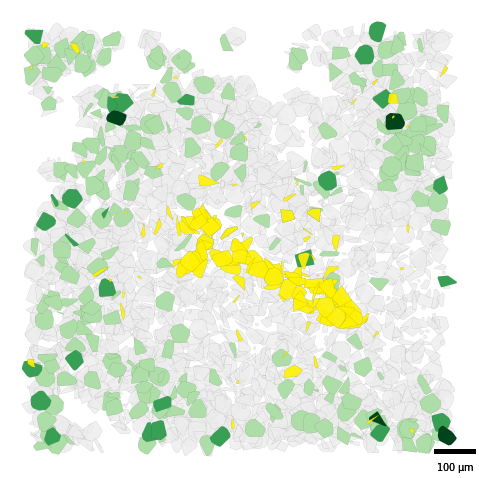

INFO:root:First filter, 209525 cells left


EPAS1


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 3.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


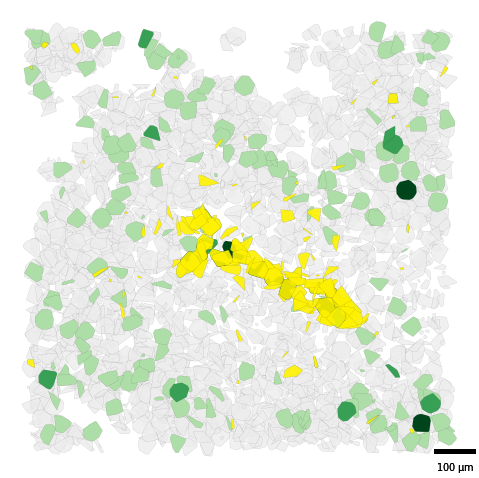

INFO:root:First filter, 209525 cells left


VEGFA


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 18.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


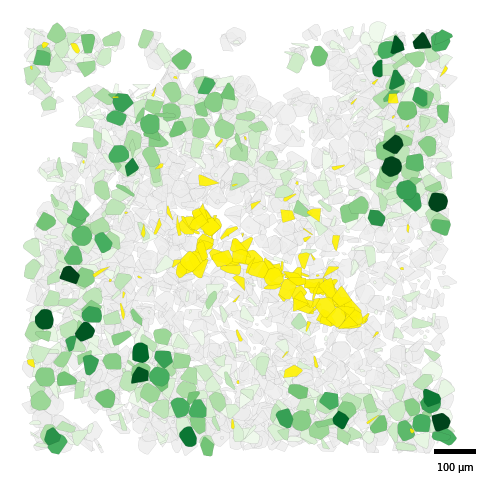

INFO:root:First filter, 209525 cells left


TGFBI


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 2.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


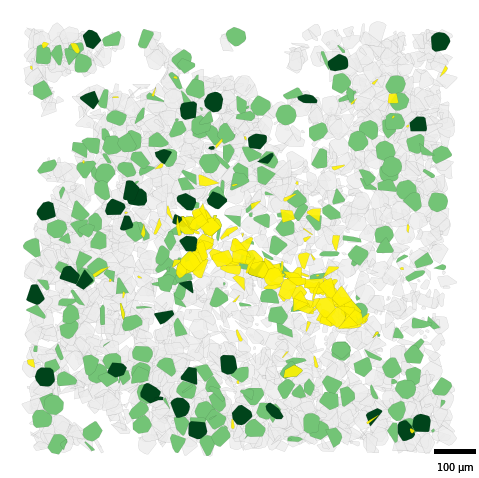

INFO:root:First filter, 209525 cells left


NOTCH1


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 2.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


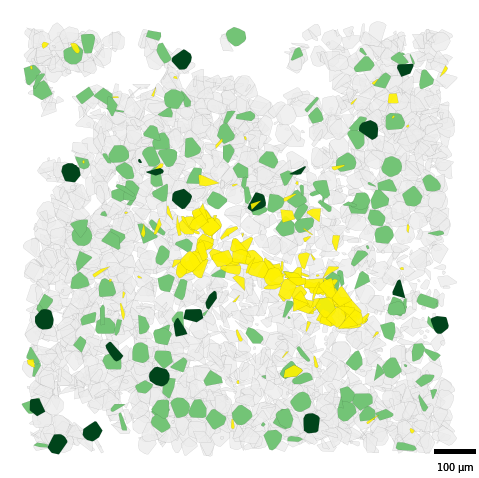

INFO:root:First filter, 209525 cells left


IGFBP5


INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 11.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


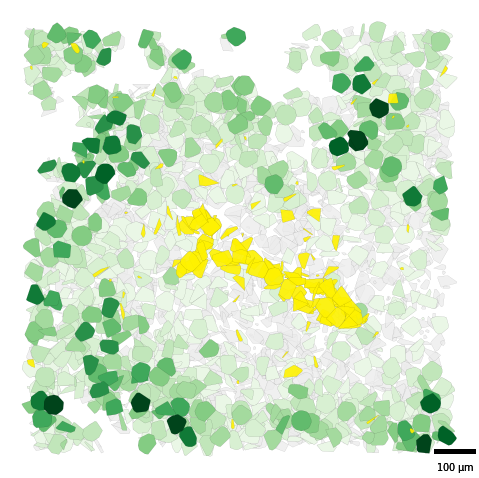

In [23]:
xlim = (11200, 12200)
ylim= (5500, 6500)

for g in ['ANXA1', 'ANXA2', 'HIF1A', 'SLC2A1', 'EPAS1', 'VEGFA', 'TGFBI', 'NOTCH1', 'IGFBP5']:
    print(g)
    fig,ax = plt.subplots(1,1 ,figsize=(5,5))
    gene = g
    sp.pl.plot_polygons_expression(
        WR,
        sample='SL035B',
        cluster_key='m-states',
        genes=[gene],
        cmap='Greens',
        xlim=xlim,
        ylim=ylim,
        alpha=1,
        show_axis=False,
        #figsize=(5,5),
        mquant=0.999,
        vmin=0,
        #vmax=np.quantile(WR[:,gene], .99),
        ax = ax
    
    )
    
    sp.pl.plot_polygons(
        adata,
        sample='SL035B',
        cluster_key='m-states',
        clusters=['Mural','Endothelial'], #[45,76],
        xlim=xlim,
        ylim=ylim,
        alpha=0.9,
        show_axis=True,
        palette= {'Endothelial':'#fff200','Mural': '#fff200',},
        ax=ax,
    )
    
    #plt.savefig(f'figures/{g}.png',dpi=300, format='png', transparent=True,bbox_inches='tight')
    plt.show()

INFO:root:First filter, 209525 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 4.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


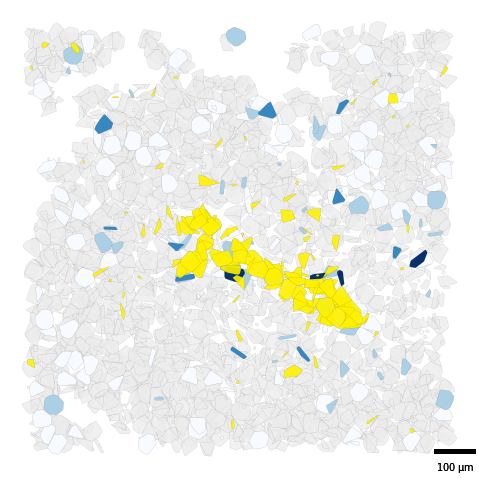

In [27]:
xlim = (11200, 12200)
ylim= (5500, 6500)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))

sp.pl.plot_polygons_expression(
    WR,
    sample='SL035B',
    genes=['MGP'],
    cluster_key='m-states',
    cmap='Blues',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    show_axis=False,
    mquant=0.999,
    ax = ax

)

sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#fff200','Mural': '#fff200',},
    ax=ax,
)

plt.show()

INFO:root:First filter, 209525 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 3.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


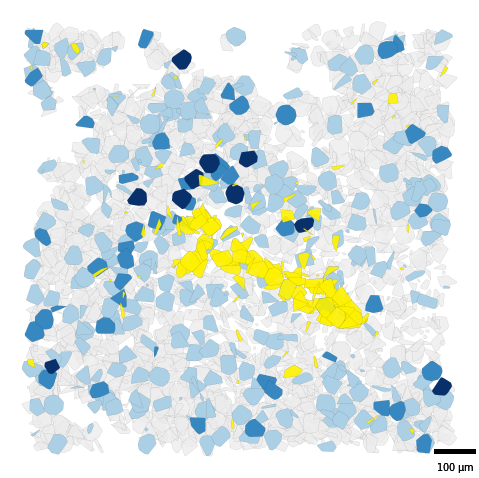

In [35]:
xlim = (11200, 12200)
ylim= (5500, 6500)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))

sp.pl.plot_polygons_expression(
    WR,
    sample='SL035B',
    genes=['PLAU'],
    cluster_key='m-states',
    cmap='Blues',
    xlim=xlim,
    ylim=ylim,
    alpha=1,
    vmin=0,
    show_axis=False,
    mquant=0.999,
    ax = ax

)

sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#fff200','Mural': '#fff200',},
    ax=ax,
)

plt.show()

INFO:root:First filter, 209525 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 2502 cells left
INFO:root:Expression range: 1.0 - 3.0
INFO:root:First filter, 7656 cells left
INFO:root:Selecting cells in zoom area
INFO:root:Zoom filter, 151 cells left
/Users/amossi/Documents/code/FISHspace/plotting/polygons.py:138: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  _ = gdf[gdf[cluster_key].isin(grey_clusters)].plot(


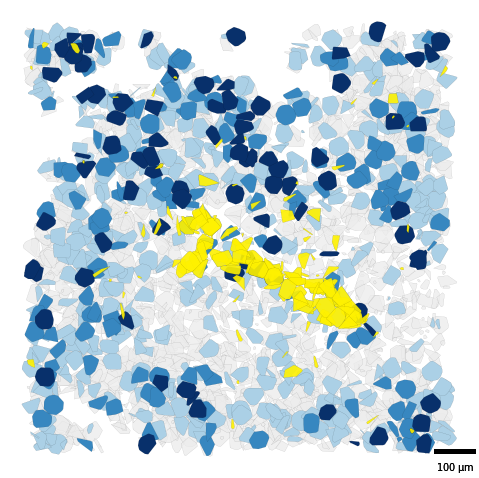

In [33]:
xlim = (11200, 12200)
ylim= (5500, 6500)

fig,ax = plt.subplots(1,1 ,figsize=(5,5))

sp.pl.plot_polygons_expression(
    WR,
    sample='SL035B',
    genes=['SERPINE1'],
    cluster_key='m-states',
    cmap='Blues',
    xlim=xlim,
    ylim=ylim,
    vmin=0,
    alpha=1,
    show_axis=False,
    mquant=0.99,
    ax = ax

)

sp.pl.plot_polygons(
    adata,
    sample='SL035B',
    cluster_key='m-states',
    clusters=['Mural','Endothelial'], #[45,76],
    xlim=xlim,
    ylim=ylim,
    alpha=0.9,
    show_axis=True,
    palette= {'Endothelial':'#fff200','Mural': '#fff200',},
    ax=ax,
)

plt.show()